In [1]:
!pip install opencv-python opencv-contrib-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving img1.png to img1.png
Saving img2.png to img2.png


In [3]:
class ImageUtils:

    @staticmethod
    def load_image(path):
        image = cv2.imread(path)

        if image is None:
            raise Exception(f"Image not found: {path}")

        return image


    @staticmethod
    def resize_image(image, width=800):

        h, w = image.shape[:2]

        if w <= width:
            return image

        scale = width / w

        new_size = (
            width,
            int(h * scale)
        )

        return cv2.resize(image, new_size)


In [4]:
class FeatureExtractor:

    def __init__(self):
        self.sift = cv2.SIFT_create()


    def detect_and_describe(self, image):

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        keypoints, descriptors = self.sift.detectAndCompute(
            gray,
            None
        )

        return keypoints, descriptors


In [5]:
class FeatureMatcher:

    def match_features(self, descriptors1, descriptors2):

        index_params = dict(
            algorithm=1,
            trees=5
        )

        search_params = dict(
            checks=50
        )

        flann = cv2.FlannBasedMatcher(
            index_params,
            search_params
        )

        raw_matches = flann.knnMatch(
            descriptors1,
            descriptors2,
            k=2
        )

        good_matches = []

        for m, n in raw_matches:

            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

        return good_matches



In [6]:
class HomographyEstimator:

    def compute_homography(
        self,
        keypoints1,
        keypoints2,
        matches
    ):

        if len(matches) < 4:
            raise Exception("Not enough matches")

        src_points = np.float32([
            keypoints1[m.queryIdx].pt
            for m in matches
        ]).reshape(-1, 1, 2)

        dst_points = np.float32([
            keypoints2[m.trainIdx].pt
            for m in matches
        ]).reshape(-1, 1, 2)

        H, mask = cv2.findHomography(
            src_points,
            dst_points,
            cv2.RANSAC,
            5.0
        )

        return H, mask



In [7]:
class Visualizer:

    @staticmethod
    def show_image(title, image, figsize=(15,7)):

        plt.figure(figsize=figsize)

        plt.imshow(
            cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        )

        plt.title(title)

        plt.axis("off")

        plt.show()


    @staticmethod
    def draw_matches(
        image1,
        keypoints1,
        image2,
        keypoints2,
        matches,
        mask
    ):

        result = cv2.drawMatches(
            image1,
            keypoints1,
            image2,
            keypoints2,
            matches,
            None,
            matchesMask=mask.ravel().tolist(),
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )

        return result


In [9]:
class PanoramaStitcher:

    def warp_images(self, image1, image2, H):

        h1, w1 = image1.shape[:2]
        h2, w2 = image2.shape[:2]

        corners_img1 = np.float32([
            [0,0],
            [0,h1],
            [w1,h1],
            [w1,0]
        ]).reshape(-1,1,2)

        corners_img2 = np.float32([
            [0,0],
            [0,h2],
            [w2,h2],
            [w2,0]
        ]).reshape(-1,1,2)

        transformed_corners = cv2.perspectiveTransform(
            corners_img1,
            H
        )

        all_corners = np.concatenate(
            (transformed_corners, corners_img2),
            axis=0
        )

        [xmin, ymin] = np.int32(
            all_corners.min(axis=0).ravel() - 0.5
        )

        [xmax, ymax] = np.int32(
            all_corners.max(axis=0).ravel() + 0.5
        )

        translation = [-xmin, -ymin]

        translation_matrix = np.array([
            [1, 0, translation[0]],
            [0, 1, translation[1]],
            [0, 0, 1]
        ])

        panorama = cv2.warpPerspective(
            image1,
            translation_matrix @ H,
            (xmax - xmin, ymax - ymin)
        )

        panorama[
            translation[1]:translation[1] + h2,
            translation[0]:translation[0] + w2
        ] = image2

        return panorama


    def crop_black_borders(self, image):

        gray = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
        )

        _, thresh = cv2.threshold(
            gray,
            1,
            255,
            cv2.THRESH_BINARY
        )

        contours, _ = cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        largest_contour = max(
            contours,
            key=cv2.contourArea
        )

        x, y, w, h = cv2.boundingRect(
            largest_contour
        )

        cropped = image[y:y+h, x:x+w]

        return cropped



In [12]:
image1 = ImageUtils.load_image("img1.png")
image2 = ImageUtils.load_image("img2.png")

image1 = ImageUtils.resize_image(image1)
image2 = ImageUtils.resize_image(image2)

print("Images Loaded")

Images Loaded


Features Extracted


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

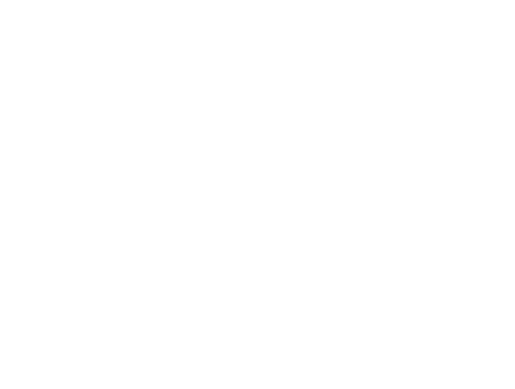

In [13]:
extractor = FeatureExtractor()

kp1, des1 = extractor.detect_and_describe(image1)
kp2, des2 = extractor.detect_and_describe(image2)

print("Features Extracted")
plt.axis("off")

In [14]:
matcher = FeatureMatcher()

matches = matcher.match_features(
    des1,
    des2
)

print("Good Matches:", len(matches))


Good Matches: 663


In [15]:
homography = HomographyEstimator()

H, mask = homography.compute_homography(
    kp1,
    kp2,
    matches
)

print("Homography Computed")

Homography Computed


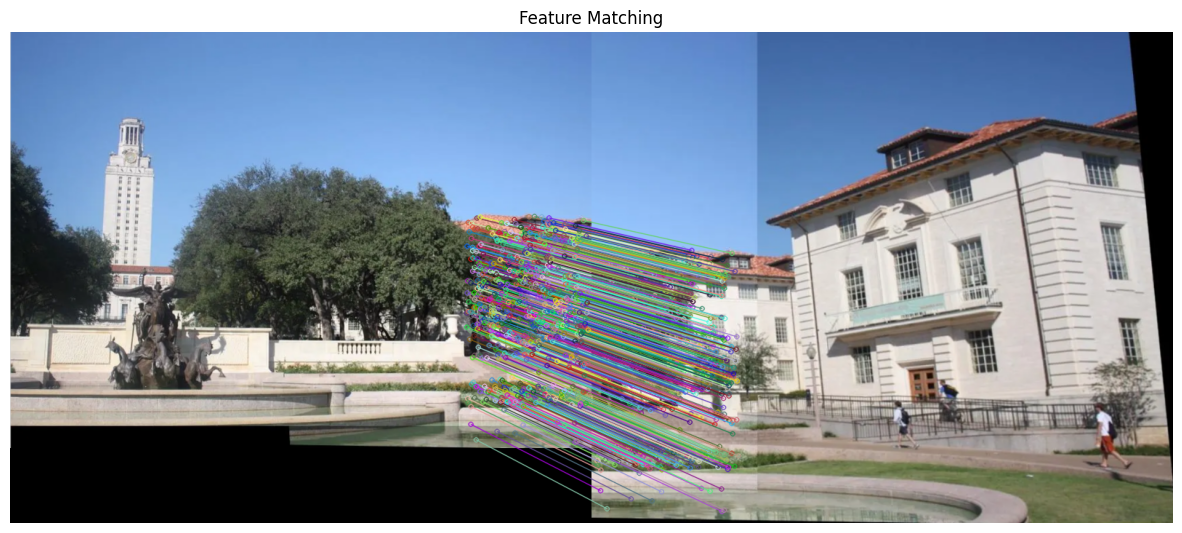

In [16]:
matched_image = Visualizer.draw_matches(
    image1,
    kp1,
    image2,
    kp2,
    matches,
    mask
)

Visualizer.show_image(
    "Feature Matching",
    matched_image
)

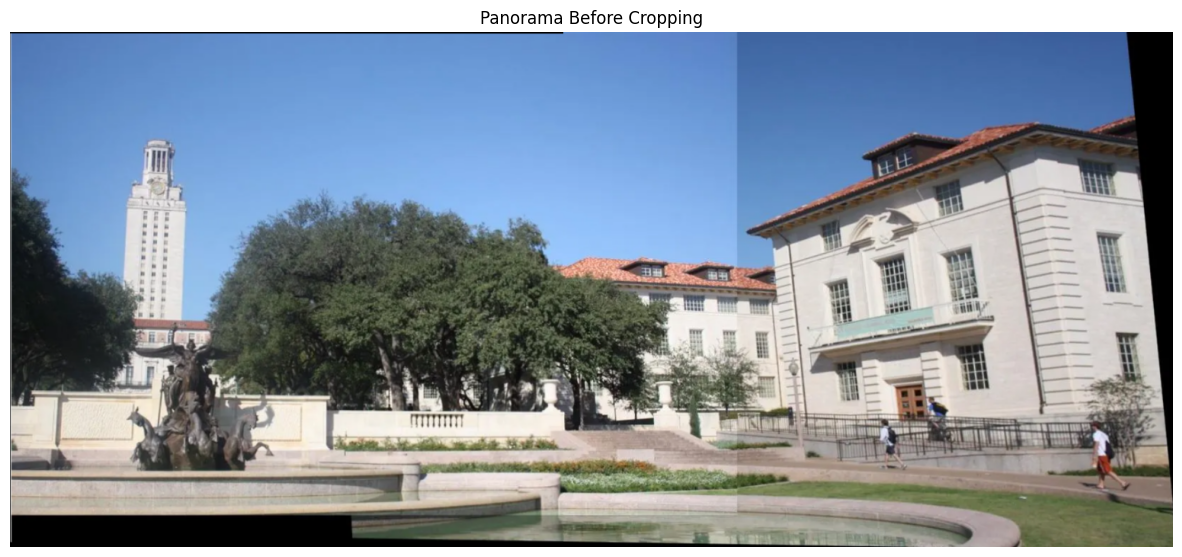

In [27]:
stitcher = PanoramaStitcher()

panorama = stitcher.warp_images(
    image1,
    image2,
    H
)

Visualizer.show_image(
    "Panorama Before Cropping",
    panorama
)



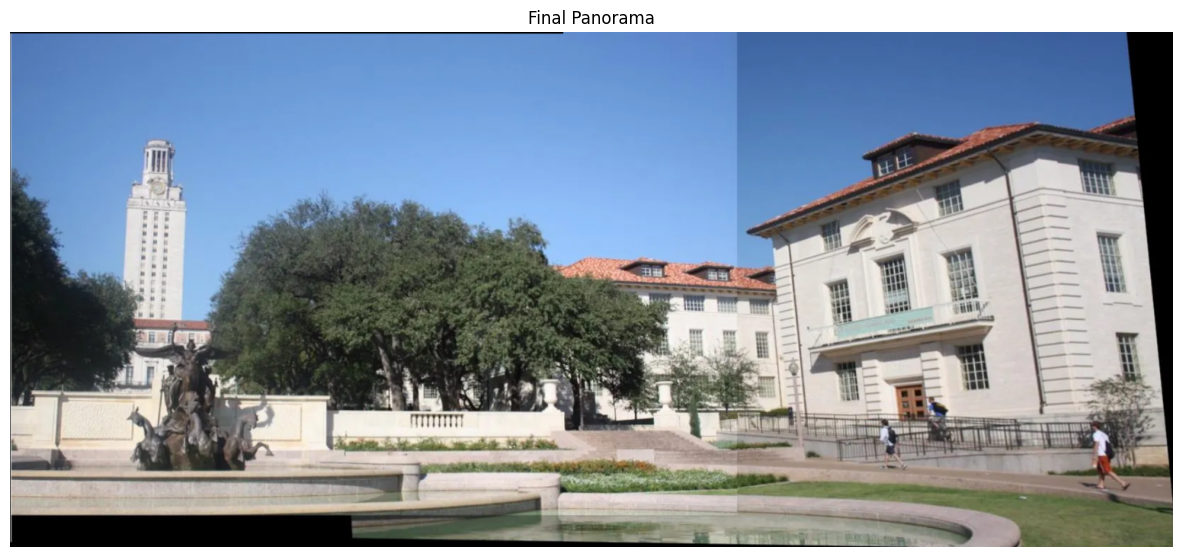

In [30]:
final_panorama = stitcher.crop_black_borders(
    panorama
)

Visualizer.show_image(
    "Final Panorama",
    final_panorama
)


In [29]:
cv2.imwrite(
    "panorama_result.jpg",
    final_panorama
)

files.download(
    "panorama_result.jpg"
)

print("Panorama Saved Successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Panorama Saved Successfully
